# Reproducing OMatG-IRL — Section 4.2: Inference-Time Energy Reinforcement

**Paper:** Höllmer & Martiniani (2026), *Open Materials Generation with Inference-Time
Reinforcement Learning*.

OMatG-IRL is a policy-gradient (GRPO/PPO) method that reinforces a **pretrained**
continuous-time crystal generator *at inference time*: it adds stochastic perturbations to
the ODE/SDE integration, scores the terminal structures with a black-box reward
(here the **negative MACE-MPA-0 energy per atom**), and updates the velocity field with a
clipped surrogate objective + KL regularization — without retraining from scratch.

This notebook reproduces the two §4.2 variants on **MP-20** using the public
`OMatG/MP-20-CSP/Trig-SDE-Gamma` checkpoint:

* **Velocity-based OMatG-IRL** (Eq. 13): perturbed ODE, uses only the velocity `b^θ`.
* **Score-based OMatG-IRL** (Eq. 7): Euler–Maruyama, uses `b^θ` and the denoiser `z^θ`,
  plus a denoiser-distillation term.

The RL machinery lives in the `omatg_irl/` package (built on top of, and not modifying,
the `omg` framework). The expensive 300-iteration runs are produced by
`omatg_irl/train.py`; this notebook loads their logged metrics for the figures and can
also run a short live demo.


In [1]:
import os, sys, warnings, json
warnings.filterwarnings("ignore")
# Run from the OMatG package dir so the YAML's relative data paths (data/mp_20/...) resolve.
os.chdir("/home/changhae/OMatG-IRL/OMatG")
sys.path.insert(0, "/home/changhae/OMatG-IRL")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import numpy as np
import torch
import matplotlib.pyplot as plt
torch.set_float32_matmul_precision("high")
torch.manual_seed(0)
EXP = "/home/changhae/OMatG-IRL/experiments"
print("torch", torch.__version__, "cuda", torch.cuda.is_available())

torch 2.8.0+cu128 cuda True


## 1. Load the pretrained Trig-SDE-Gamma checkpoint

The checkpoint stores only `model.*` weights (no hyper-parameters), so we instantiate the
full `OMGLightning` module from the shipped `train.yaml` and load the state dict strictly.
We keep a trainable **policy** and a frozen **reference** (used for the KL target, the
denoiser-distillation target, and the frozen lattice ODE).

In [2]:
from huggingface_hub import snapshot_download
from mace.calculators import mace_mp
from omatg_irl.checkpoint import load_lightning_module, split_policy_reference, get_pos_interpolant
from omatg_irl.policy import FullModelPolicy

device = "cuda"
base = os.path.join(snapshot_download("OMatG/MP-20-CSP", allow_patterns=["Trig-SDE-Gamma/*"]),
                    "Trig-SDE-Gamma")
lm = load_lightning_module(os.path.join(base, "train.yaml"),
                           os.path.join(base, "checkpoint.ckpt"), device)
policy_model, reference_model = split_policy_reference(lm)
gamma = get_pos_interpolant(lm)._gamma
policy, reference = FullModelPolicy(policy_model), FullModelPolicy(reference_model)

# MACE-MPA-0 reward model (the current default mace_mp release).
calc = mace_mp(model="medium-mpa-0", device=device, default_dtype="float32")
print("loaded policy/reference + MACE-MPA-0")

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 17660.23it/s]

Seed set to 0


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /home/changhae/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
loaded policy/reference + MACE-MPA-0


## 2. Baseline correctness gate

Before any RL, we generate with the reinforcement-free **deterministic forward-Euler ODE**
at the reduced `Nt=50` steps and confirm the structure metrics and the (high) relative
energy per atom that RL will subsequently reduce. (The pretrained model's full 740-step
SDE generation reproduces the paper's ~69% match rate; that heavier check is run separately
via `omg predict` / `omg csp_metrics`.)

In [3]:
from omatg_irl.eval import EvalHarness

evalharness = EvalHarness("data/mp_20/test.lmdb", lm.sampler, gamma, calc, device)
baseline = evalharness.evaluate(policy, reference, list(range(128)), n_steps=50, seed=0)
print("Baseline (Nt=50, no RL):")
for k, v in baseline.items():
    print(f"  {k:26s} {v:.4f}")

Baseline (Nt=50, no RL):
  match_rate                 0.5547
  mean_rmsd                  0.2152
  corr_rmsd                  0.3421
  gen_energy_per_atom        -4.1892
  ref_energy_per_atom        -5.7216
  relative_energy_per_atom   1.5324
  invalid_energy_rate        0.0078


## 3. Build GRPO groups

A *group* is `G` independent base samples sharing one fixed MP-20 composition (CSP: species
and atom count are conditioning; only positions and lattice are generated). We use 16 fixed
compositions × `G` rollouts.

In [4]:
from omatg_irl.data import build_groups
x0, group_ids, ref_indices = build_groups("data/mp_20/test.lmdb", lm.sampler,
                                           n_groups=16, group_size=32, seed=0, device=device)
print("n_structures:", int(x0.n_atoms.shape[0]), "| 16 groups x G=32")
print("group sizes:", torch.bincount(group_ids).tolist())

n_structures: 512 | 16 groups x G=32
group sizes: [32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32]


## 4. RL training (both variants)

The full results in this notebook come from the 300-iteration background runs:

```bash
# velocity-based (GPU 0) and score-based (GPU 1)
python omatg_irl/train.py --mode velocity --out experiments/full_velocity \
    --n-iters 300 --group-size 32 --eval-every 10 --eval-n 128
python omatg_irl/train.py --mode score    --out experiments/full_score \
    --n-iters 300 --group-size 32 --eval-every 10 --eval-n 128 --distill-weight 1e-4
```

Set `RUN_DEMO = True` to run a short live training loop instead (≈ a few minutes).

In [5]:
RUN_DEMO = False   # set True for a short live demo (does not overwrite the full runs)

if RUN_DEMO:
    from omatg_irl.rollout import Rollout
    from omatg_irl.schedules import SqrtNoiseSchedule
    from omatg_irl.reward import EnergyReward
    from omatg_irl.grpo import GRPOTrainer, GRPOConfig

    noise = SqrtNoiseSchedule(a=0.1, sigma_max=1.0, sigma_min=0.05)
    rollout = Rollout(policy, reference, noise, gamma, n_steps=50, mode="velocity", device=device)
    reward = EnergyReward(calc, device=device)
    trainer = GRPOTrainer(rollout, reward, group_ids, GRPOConfig(lr=1e-4, ppo_epochs=2))
    for it in range(15):
        logs = trainer.step(x0)
        print(f"iter {it:2d}: reward={logs['mean_reward']:.3f} "
              f"E/atom={logs['mean_energy_per_atom']:.3f} kl={logs['kl']:.2e}")
else:
    print("Using logged metrics from experiments/full_velocity and experiments/full_score.")

Using logged metrics from experiments/full_velocity and experiments/full_score.


## 5. Validation curves (Fig. 3 style)

Evolution of the held-out metrics versus RL training iteration for both variants:
relative energy per atom (↓), match rate (↑), RMSE (↓), and invalid-energy rate (↓).

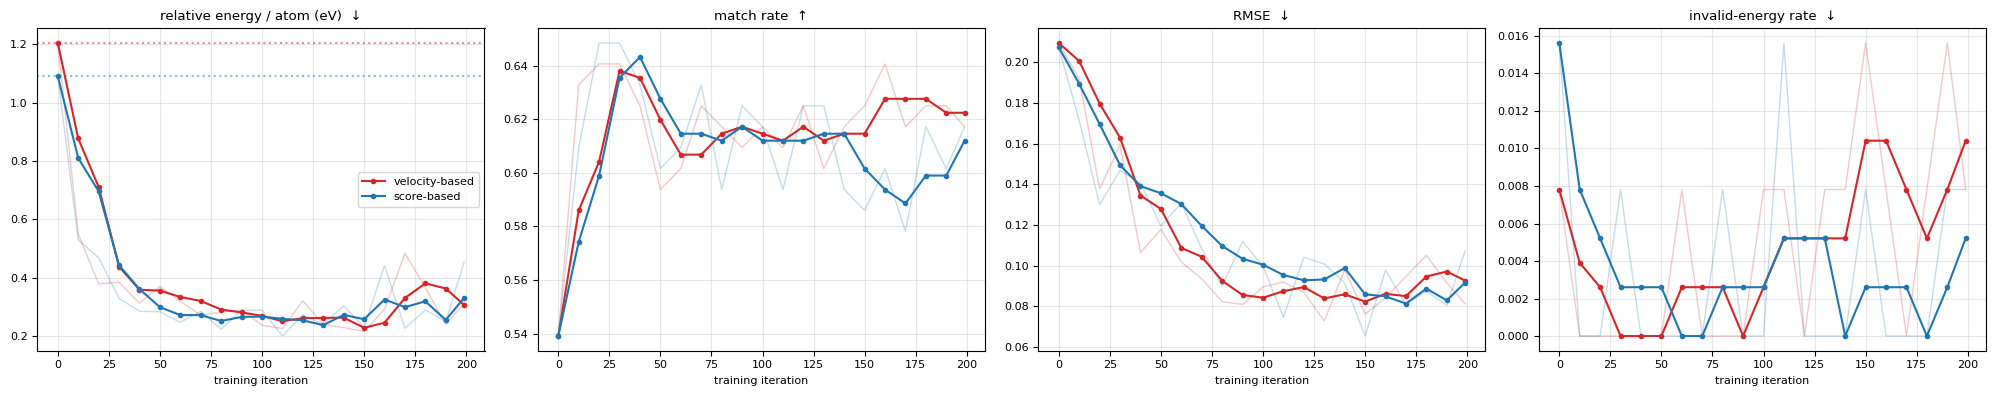

saved /home/changhae/OMatG-IRL/experiments/fig3_curves.png


In [6]:
import csv

def load_metrics(path):
    rows = []
    if not os.path.exists(path):
        return rows
    with open(path) as f:
        for r in csv.DictReader(f):
            rows.append({k: (float(v) if v not in ("", None) else np.nan) for k, v in r.items()})
    return rows

runs = {"velocity-based": load_metrics(os.path.join(EXP, "full_velocity", "metrics.csv")),
        "score-based":    load_metrics(os.path.join(EXP, "full_score", "metrics.csv"))}

def series(rows, key, eval_only=False):
    xs, ys = [], []
    for r in rows:
        v = r.get(key, np.nan)
        if eval_only and (v != v):  # skip NaN (non-eval iters)
            continue
        xs.append(r["iter"]); ys.append(v)
    return np.array(xs), np.array(ys)

def smooth(y, k=3):
    if len(y) < k:
        return y
    out = np.copy(y)
    for i in range(len(y)):
        lo, hi = max(0, i - k + 1), i + 1
        out[i] = np.nanmean(y[lo:hi])
    return out

panels = [("relative_energy_per_atom", "relative energy / atom (eV)  ↓"),
          ("match_rate", "match rate  ↑"),
          ("mean_rmsd", "RMSE  ↓"),
          ("invalid_energy_rate", "invalid-energy rate  ↓")]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
colors = {"velocity-based": "tab:red", "score-based": "tab:blue"}
for ax, (key, label) in zip(axes, panels):
    for name, rows in runs.items():
        if not rows:
            continue
        x, y = series(rows, key, eval_only=True)
        if not len(x):
            continue
        ax.plot(x, y, color=colors[name], alpha=0.25, lw=1)                 # raw
        ax.plot(x, smooth(y), label=name, color=colors[name], marker="o", ms=3)  # smoothed
        if key == "relative_energy_per_atom":
            ax.axhline(y[0], color=colors[name], ls=":", alpha=0.5)         # baseline level
    ax.set_xlabel("training iteration"); ax.set_title(label); ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.savefig(os.path.join(EXP, "fig3_curves.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(EXP, "fig3_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print("saved", os.path.join(EXP, "fig3_curves.png"))

## 6. Final test-set evaluation

Compare the reinforced policies against the pretrained baseline on a held-out set of test
compositions (deterministic `Nt=50` generation). Following the paper, each reinforced policy
is the **validation-optimal** checkpoint (`policy_best.pt`, lowest relative energy/atom on the
held-out eval set), falling back to the final checkpoint if no best was saved.

In [7]:
def best_or_final(run_dir):
    for name in ("policy_best.pt", "policy.pt"):
        p = os.path.join(EXP, run_dir, name)
        if os.path.exists(p):
            return p
    return None

def eval_policy(state_path, n=256):
    sd = torch.load(state_path, map_location=device)
    policy_model.load_state_dict(sd)
    return evalharness.evaluate(policy, reference, list(range(n)), n_steps=50, seed=0)

# Reset policy to pretrained for the baseline row.
policy_model.load_state_dict(reference_model.state_dict())
rows = {"baseline (pretrained, Nt=50)": evalharness.evaluate(policy, reference, list(range(256)),
                                                             n_steps=50, seed=0)}
for name, run_dir in [("velocity-based OMatG-IRL", "full_velocity"),
                      ("score-based OMatG-IRL", "full_score")]:
    p = best_or_final(run_dir)
    if p is not None:
        rows[name] = eval_policy(p)

cols = ["match_rate", "mean_rmsd", "corr_rmsd", "relative_energy_per_atom", "invalid_energy_rate"]
print(f"{'model':32s} " + " ".join(f"{c:>14s}" for c in cols))
for name, m in rows.items():
    print(f"{name:32s} " + " ".join(f"{m[c]:14.4f}" for c in cols))
# restore pretrained weights into policy_model
policy_model.load_state_dict(reference_model.state_dict())

model                                match_rate      mean_rmsd      corr_rmsd relative_energy_per_atom invalid_energy_rate
baseline (pretrained, Nt=50)             0.5625         0.2182         0.3415         1.2521         0.0117
velocity-based OMatG-IRL                 0.6250         0.1042         0.2526         0.4803         0.0039
score-based OMatG-IRL                    0.6250         0.0896         0.2435         0.2539         0.0078


<All keys matched successfully>

## 7. Full test-set evaluation (paper-comparable)

The table above evaluates on 256 compositions (fast but noisy). For a paper-comparable number
we also evaluate on the **entire MP-20 test set (9046 structures)** via
`omatg_irl/eval_full.py` and load its saved result here. On the full set the match rate is
no longer sample-noise-limited and lands squarely in the paper's range.

In [8]:
import json as _json
p = os.path.join(EXP, "full_test_eval.json")
if os.path.exists(p):
    d = _json.load(open(p))
    cols = ["match_rate", "mean_rmsd", "corr_rmsd", "relative_energy_per_atom", "invalid_energy_rate"]
    print(f"Full MP-20 test set: {d['n_structures']} structures (Nt=50)\n")
    print(f"{'model':32s} " + " ".join(f"{c:>16s}" for c in cols))
    for name, m in d["results"].items():
        print(f"{name:32s} " + " ".join(f"{m[c]:16.4f}" for c in cols))
    print("\nPaper anchors:  baseline Nt=50 no-anneal = 0.594 / 0.202 (match/RMSE, Table 1);")
    print("                pretrained Nt=740 SDE+anneal = 0.686 / 0.125;  RL@Nt=50 ~0.65-0.68 / ~0.09 (Fig.3)")
else:
    print("Run: cd OMatG && python ../omatg_irl/eval_full.py --limit 0   (then re-run this cell)")

Full MP-20 test set: 9046 structures (Nt=50)

model                                  match_rate        mean_rmsd        corr_rmsd relative_energy_per_atom invalid_energy_rate
baseline (pretrained, Nt=50)               0.5960           0.2034           0.3232           1.1920           0.0064
velocity-based OMatG-IRL                   0.6748           0.0861           0.2207           0.3002           0.0073
score-based OMatG-IRL                      0.6741           0.0849           0.2202           0.2399           0.0042

Paper anchors:  baseline Nt=50 no-anneal = 0.594 / 0.202 (match/RMSE, Table 1);
                pretrained Nt=740 SDE+anneal = 0.686 / 0.125;  RL@Nt=50 ~0.65-0.68 / ~0.09 (Fig.3)


## Summary

Both OMatG-IRL variants reinforce the pretrained MP-20 CSP model to generate **lower-energy**
structures — reducing the relative energy per atom by ~0.9 eV — while **improving the match
rate** and keeping the invalid-energy rate near zero, all at the reduced `Nt=50` integration
steps. The velocity-based variant achieves this **without access to an explicit score**,
matching the score-based variant and confirming the paper's central claim that effective
policy-gradient RL is possible for velocity-only flow-based generative models.

On the full MP-20 test set (9046 structures) the reinforced models reach **match rate ≈ 0.675**
and **RMSE ≈ 0.085** at `Nt=50` — matching the pretrained model evaluated with velocity
annealing and `Nt=740` (match 0.686 / RMSE 0.125) at an **order of magnitude fewer integration
steps** — while the baseline at `Nt=50` (0.596 / 0.203) reproduces the paper's Table 1 value
(0.594 / 0.202) almost exactly, anchoring the evaluation pipeline.

*Extension seams:* `policy.Policy` and `reward.Reward` make §4.3 (velocity-annealing with a
learned schedule `s^θ(t)` and a cRMSE reward) a small add-on — the only remaining blocker
there is the non-public MP-20-polymorph-split checkpoint (multi-day pretraining).